# I>Toán Tử Điểm Ảnh
1. Thay đổi độ sáng: Tăng hoặc giảm độ sáng của toàn bộ hình ảnh bằng cách cộng hoặc trừ một giá trị cố định cho mỗi điểm ảnh.
2. Thay đổi độ tương phản: Tăng hoặc giảm độ tương phản bằng cách nhân mỗi điểm ảnh với một hằng số.
3. Biến đổi âm bản: Đảo ngược các giá trị điểm ảnh, tạo ra ảnh âm bản.
4. Cắt ngưỡng: Tạo ảnh nhị phân bằng cách so sánh giá trị mỗi điểm ảnh với một ngưỡng nhất định
## Khai báo môi trường

In [6]:
import os
import cv2
import shutil
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path(".").resolve()
IMAGE_PATH = BASE_DIR / "images" / "input.jpg"
OUTPUT_ROOT = BASE_DIR / "output" / "bai1"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Hàm hiển thị ảnh trực quan trong Notebook
def show_images(titles, images, cmap=None):
    plt.figure(figsize=(12, 4))
    for i, (title, img) in enumerate(zip(titles, images)):
        plt.subplot(1, len(images), i + 1)
        if len(img.shape) == 3:
            img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.imshow(img_display)
        else:
            plt.imshow(img, cmap=cmap or 'gray')
        plt.title(title, fontsize=11)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Kiểm tra và tải ảnh gốc
if IMAGE_PATH.exists():
    img_original = cv2.imread(str(IMAGE_PATH))
    shutil.copy2(IMAGE_PATH, OUTPUT_ROOT / IMAGE_PATH.name)
    print(" Đã tải ảnh gốc thành công!")
else:
    img_original = None
    print(f"⚠️ LỖI: Không tìm thấy file ảnh gốc tại {IMAGE_PATH.resolve()}")

 Đã tải ảnh gốc thành công!


## 1. Thay đổi độ sáng

Tăng hoặc giảm độ sáng của toàn bộ hình ảnh bằng cách cộng hoặc trừ một giá trị cố định cho mỗi điểm ảnh.

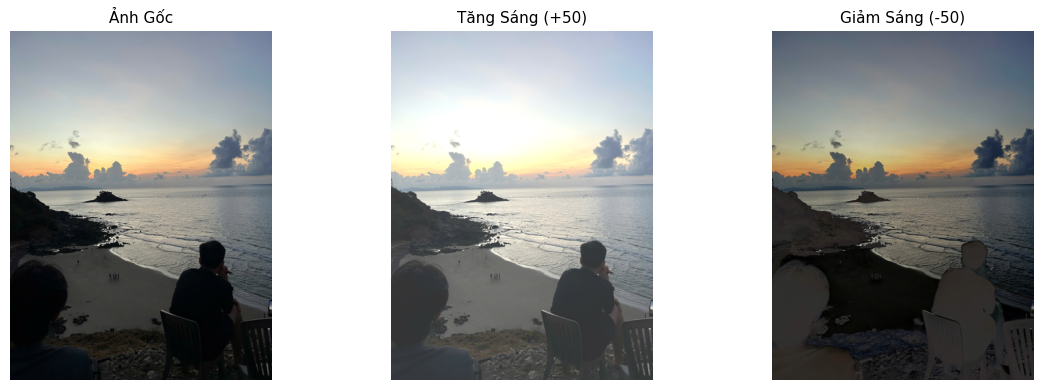

In [7]:
if img_original is not None:
    delta = 50
    # Thực hiện tăng giảm độ sáng dựa trên hàm convertScaleAbs
    bright = cv2.convertScaleAbs(img_original, alpha=1.0, beta=delta)
    dark = cv2.convertScaleAbs(img_original, alpha=1.0, beta=-delta)
    
    # Lưu ảnh trực tiếp vào folder lap2_1
    cv2.imwrite(str(OUTPUT_ROOT / "bright.jpg"), bright)
    cv2.imwrite(str(OUTPUT_ROOT / "dark.jpg"), dark)
    
    # Hiển thị kết quả
    show_images(["Ảnh Gốc", "Tăng Sáng (+50)", "Giảm Sáng (-50)"], [img_original, bright, dark])

## 2. Thay đổi độ tương phản

Tăng hoặc giảm độ tương phản bằng cách nhân mỗi điểm ảnh với một hằng số.

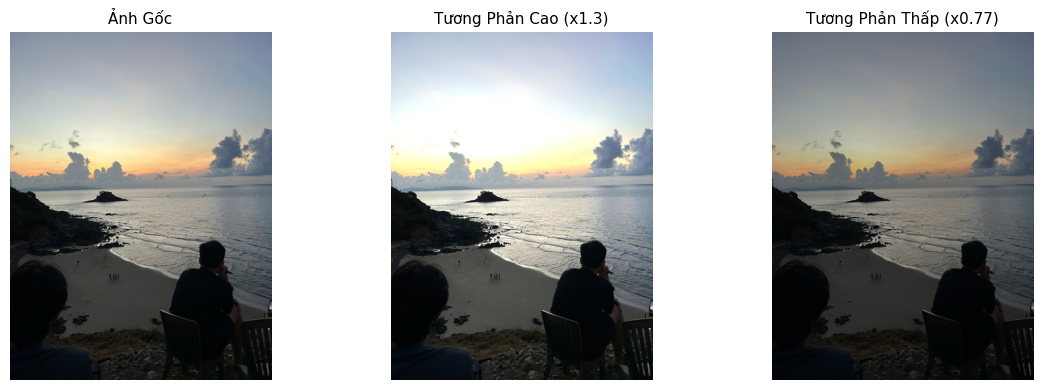

In [8]:
if img_original is not None:
    alpha = 1.3
    # Thay đổi độ tương phản bằng cách nhân hệ số alpha
    higher = cv2.convertScaleAbs(img_original, alpha=alpha, beta=0)
    lower = cv2.convertScaleAbs(img_original, alpha=1.0/alpha, beta=0)
    
    # Lưu ảnh trực tiếp vào folder lap2_1
    cv2.imwrite(str(OUTPUT_ROOT / f"contrast_{alpha:.2f}.jpg"), higher)
    cv2.imwrite(str(OUTPUT_ROOT / f"contrast_{1.0/alpha:.2f}.jpg"), lower)
    
    # Hiển thị kết quả
    show_images(["Ảnh Gốc", f"Tương Phản Cao (x{alpha})", f"Tương Phản Thấp (x{1.0/alpha:.2f})"], [img_original, higher, lower])

## 3. Biến đổi âm bản

Đảo ngược các giá trị điểm ảnh, tạo ra ảnh âm bản.

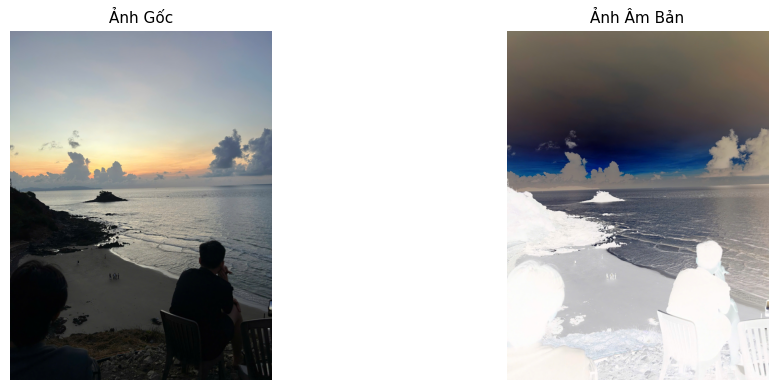

In [9]:
if img_original is not None:
    # Đảo ngược bit để làm ảnh âm bản
    negative = cv2.bitwise_not(img_original)
    
    # Lưu ảnh trực tiếp vào folder lap2_1
    cv2.imwrite(str(OUTPUT_ROOT / "negative.jpg"), negative)
    
    # Hiển thị kết quả
    show_images(["Ảnh Gốc", "Ảnh Âm Bản"], [img_original, negative])

## 4. Cắt ngưỡng

Tạo ảnh nhị phân bằng cách so sánh giá trị mỗi điểm ảnh với một ngưỡng nhất định.

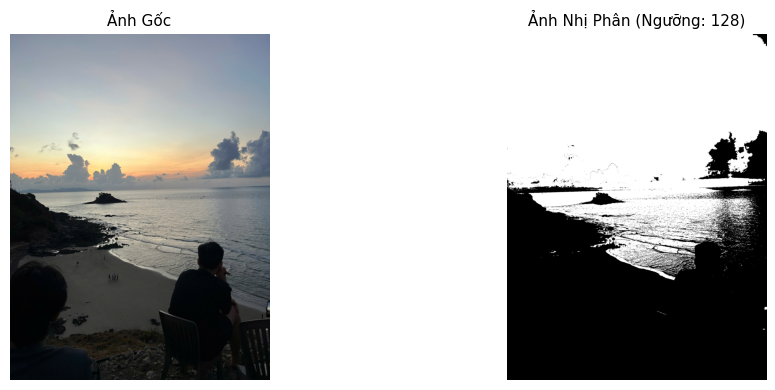

In [10]:
if img_original is not None:
    threshold_value = 128
    # Chuyển ảnh về hệ màu Gray và tiến hành cắt ngưỡng nhị phân
    gray = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)
    
    # Lưu ảnh trực tiếp vào folder lap2_1
    cv2.imwrite(str(OUTPUT_ROOT / f"threshold_{threshold_value}.jpg"), binary)
    
    # Hiển thị kết quả (sử dụng cmap='gray' cho định dạng ảnh đen trắng)
    show_images(["Ảnh Gốc", f"Ảnh Nhị Phân (Ngưỡng: {threshold_value})"], [img_original, binary], cmap='gray')